In [1]:
import kagglehub
import pandas as pd

/home/maciek/.pyenv/versions/knime/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download dataset:

KAGGLE: https://www.kaggle.com/datasets/amirmotefaker/supply-chain-dataset

In [48]:
# Download latest version
path = kagglehub.dataset_download("amirmotefaker/supply-chain-dataset")

print(f"Path to dataset files: {path}\n")

csv_name = 'supply_chain_data.csv'
full_path = f"{path}/{csv_name}"
df = pd.read_csv(full_path)

print(df.dtypes)
df.head()

Path to dataset files: /home/maciek/.cache/kagglehub/datasets/amirmotefaker/supply-chain-dataset/versions/1

Product type                   str
SKU                            str
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics          str
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers              str
Shipping costs             float64
Supplier name                  str
Location                       str
Lead time                    int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results             str
Defect rates               float64
Transportation modes           str
Routes                         str
Costs                      float64
dtype: object


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


/tmp/ipykernel_10637/436853908.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




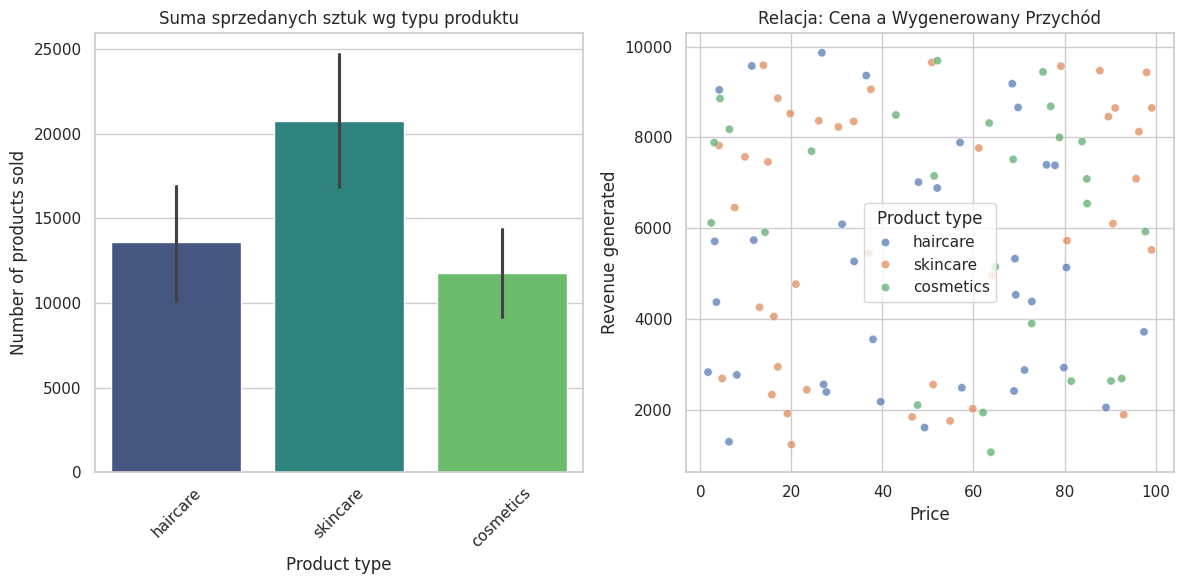

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Wykres słupkowy: Sprzedaż wg kategorii
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Product type', y='Number of products sold', estimator=sum, palette='viridis')
plt.title('Suma sprzedanych sztuk wg typu produktu')
plt.xticks(rotation=45)

# 2. Wykres punktowy: Cena vs Przychód
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Price', y='Revenue generated', hue='Product type', alpha=0.7)
plt.title('Relacja: Cena a Wygenerowany Przychód')

plt.tight_layout()
plt.show()

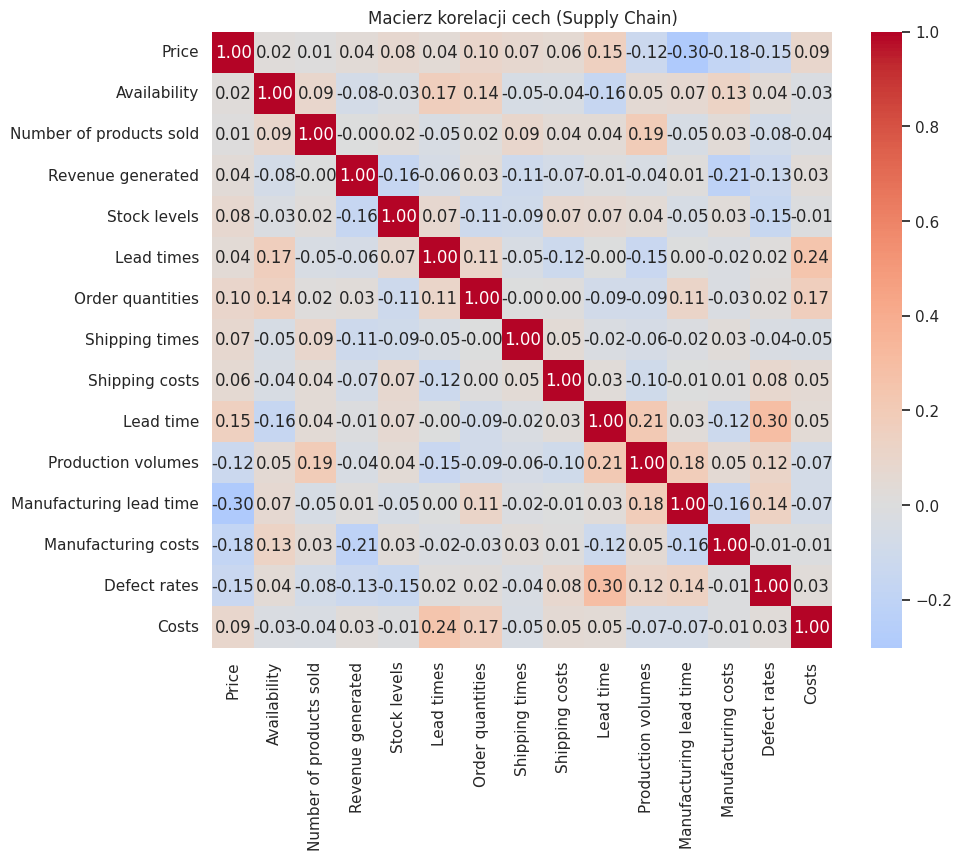

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tworzymy macierz korelacji dla wszystkich cech numerycznych
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Macierz korelacji cech (Supply Chain)')
plt.show()

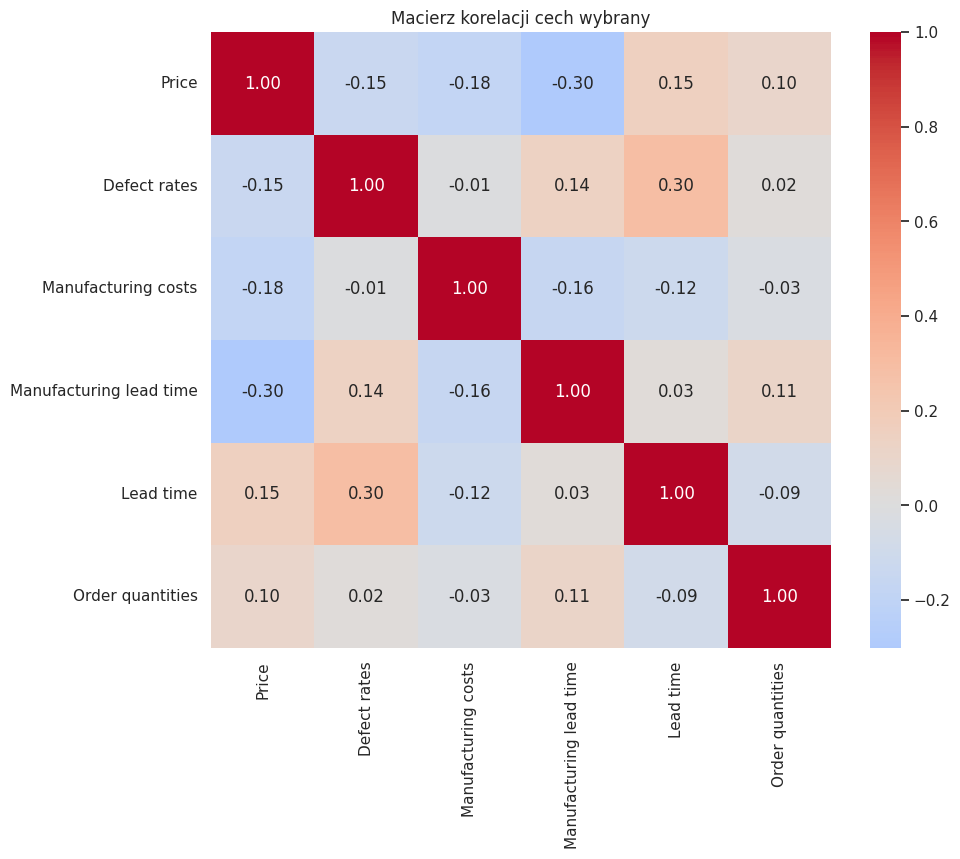

In [31]:
df_test = df[['Price', 'Defect rates', 'Manufacturing costs', 'Manufacturing lead time', 'Lead time', 'Order quantities']]

corr_matrix = df_test.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Macierz korelacji cech wybrany')
plt.show()



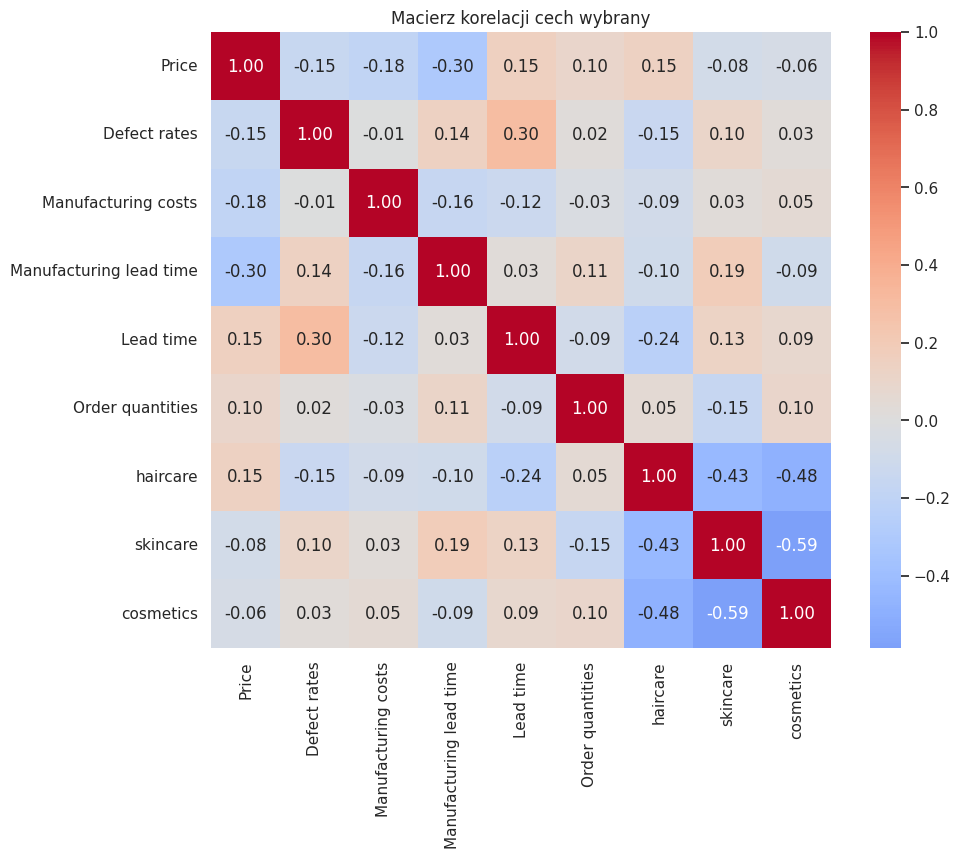

In [43]:
corr_matrix = df_test.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Macierz korelacji cech wybrany')
plt.show()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'string']).head()
x_categorical = categorical_columns.drop('SKU', axis=1)
x_categorical.columns

Index(['Product type', 'Customer demographics', 'Shipping carriers',
       'Supplier name', 'Location', 'Inspection results',
       'Transportation modes', 'Routes'],
      dtype='str')

In [77]:
# OneHotEncoder expects a 2D array
encoder = OneHotEncoder(handle_unknown='ignore')
x_encoded = encoder.fit_transform(x_categorical)

cat_column_names = [f'{col}_{cat}' for i, col in enumerate(x_categorical.columns) for cat in encoder.categories_[i]]
cat_column_names

['Product type_haircare',
 'Product type_skincare',
 'Customer demographics_Female',
 'Customer demographics_Non-binary',
 'Customer demographics_Unknown',
 'Shipping carriers_Carrier A',
 'Shipping carriers_Carrier B',
 'Shipping carriers_Carrier C',
 'Supplier name_Supplier 1',
 'Supplier name_Supplier 3',
 'Supplier name_Supplier 5',
 'Location_Delhi',
 'Location_Kolkata',
 'Location_Mumbai',
 'Inspection results_Fail',
 'Inspection results_Pending',
 'Transportation modes_Air',
 'Transportation modes_Rail',
 'Transportation modes_Road',
 'Routes_Route A',
 'Routes_Route B',
 'Routes_Route C']

In [78]:
x_encoded = x_encoded.toarray()

one_hot_features = pd.DataFrame(x_encoded, columns=cat_column_names)
one_hot_features.head()

,Product type_haircare,Product type_skincare,Customer demographics_Female,Customer demographics_Non-binary,Customer demographics_Unknown,Shipping carriers_Carrier A,Shipping carriers_Carrier B,Shipping carriers_Carrier C,Supplier name_Supplier 1,Supplier name_Supplier 3,...,Location_Kolkata,Location_Mumbai,Inspection results_Fail,Inspection results_Pending,Transportation modes_Air,Transportation modes_Rail,Transportation modes_Road,Routes_Route A,Routes_Route B,Routes_Route C
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [79]:
# Uncomment to run after kernel restart <====================

df_test = df_test.join(one_hot_features)
df_test.head()

,Price,Defect rates,Manufacturing costs,Manufacturing lead time,Lead time,Order quantities,haircare,skincare,cosmetics,Product type_haircare,...,Location_Kolkata,Location_Mumbai,Inspection results_Fail,Inspection results_Pending,Transportation modes_Air,Transportation modes_Rail,Transportation modes_Road,Routes_Route A,Routes_Route B,Routes_Route C
0,69.808006,0.226410,46.279879,29,29,96,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,14.843523,4.854068,33.616769,30,23,37,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,11.319683,4.580593,30.688019,27,12,88,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61.163343,4.746649,35.624741,18,24,59,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,4.805496,3.145580,92.065161,3,5,56,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
categorical_columns

,Product type,Customer demographics,Shipping carriers,Supplier name,Location,Inspection results,Transportation modes,Routes
0,haircare,Non-binary,Carrier B,Supplier 3,Mumbai,Pending,Road,Route B
1,skincare,Female,Carrier A,Supplier 3,Mumbai,Pending,Road,Route B
2,haircare,Unknown,Carrier B,Supplier 1,Mumbai,Pending,Air,Route C
3,skincare,Non-binary,Carrier C,Supplier 5,Kolkata,Fail,Rail,Route A
4,skincare,Non-binary,Carrier A,Supplier 1,Delhi,Fail,Air,Route A


In [ ]:
from sklearn.preprocessing import OneHotEncoder
X_num = df.select_dtypes(exclude='object')
X_cat = df.select_dtypes(include='object')
encoder = OneHotEncoder(sparse=False, handle_unknown='error')
X_encoded = encoder.fit_transform(X_cat)
X_encoded